# Enhanced Two-Step Floating Catchment Area (E2SFCA) Accessibility Analysis

This analysis uses the Enhanced Two-Step Floating Catchment Area (E2SFCA) method to assess how easily people can access hospitals in Dublin City. It takes into account travel times on the road, population data, and how distance affects usage. First, it calculates the supply-demand ratios of hospitals based on weighted population demand within specified areas. Then, it links these ratios to smaller areas to determine accessibility scores that show how well people can reach nearby hospitals. The analysis is done for both peak and off-peak times,  allowing comparison of temporal variations in healthcare accessibility across the study area.

In [302]:
#Imports required library
import os
import geopandas as gpd
import matplotlib.pyplot as plt
# %matplotlib inline

In [252]:
#Defines common data path
data_path=r"D:\GIS-TU Dublin\Year_2\THESIS\DCC_Analysis"

In [253]:
#imports the Origin Destination Lines (Output from OD Cost Matrix Solver) for peak and off-peak from hospital to small areas and small areas to hospital
OD_SA2H_Peak=gpd.read_file(data_path + r'\Data_used\ODLines_E2FSCA\OD_SA2H_Peak.shp')
OD_SA2H_OffPeak=gpd.read_file(data_path + r'\Data_used\ODLines_E2FSCA\OD_SA2H_OffPeak.shp')
OD_H2SA_Peak=gpd.read_file(data_path + r'\Data_used\ODLines_E2FSCA\OD_H2SA_Peak.shp')
OD_H2SA_OffPeak=gpd.read_file(data_path + r'\Data_used\ODLines_E2FSCA\OD_H2SA_OffPeak.shp')

In [254]:
#Displays first few rows
OD_SA2H_Peak.head(2)

,Name,OriginID,Destinatio,Destinat_1,Total_Publ,Total_Walk,Total_Leng,Shape_Leng,geometry
0,"268098009 - Saint James's Hospital,",1,4,1,14.213933,0.0,0.0,1410.326382,"LINESTRING (714764.084 734132.340, 713478.482 ..."
1,"268098009 - Saint James's Hospital,",1,9,2,14.213933,0.0,0.0,1410.326382,"LINESTRING (714764.084 734132.340, 713478.482 ..."


In [255]:
#Displays first few rows
OD_H2SA_Peak.head(2)

,Name,OriginID,Destinatio,Destinat_1,Total_Publ,Total_Walk,Total_Leng,Shape_Leng,geometry
0,Beaumont Hospital - 268022015,1,2209,1,3.376491,0.0,0.0,199.331517,"LINESTRING (718034.222 739494.617, 718069.563 ..."
1,Beaumont Hospital - 268089001,1,1027,2,5.143351,0.0,0.0,107.144798,"LINESTRING (718034.222 739494.617, 718114.582 ..."


In [256]:
## Function to clean and standardise OD matrix outputs
def clean_od(df):
    df = df.copy()
    # Find any field starting with 'Total_Pub'
    for col in df.columns:
        if col.lower().startswith("total_pub"):
            df = df.rename(columns={col: "PT_time"})
     # Extract SA_ID from Name (works for "2680... - Hospital" AND "Hospital - 2680...")
    if "Name" in df.columns:
        name = df["Name"].astype(str)

        # Try digits at start
        sa_start = name.str.extract(r"^\s*(\d+)\s*")[0]

        # If not found, try digits at end
        sa_end = name.str.extract(r"(\d+)\s*$")[0]

        # Prefer start; otherwise use end
        df["SA_ID"] = sa_start.fillna(sa_end)

#         # Convert to nullable integer
#         df["SA_ID"] = pd.to_numeric(df["SA_ID"], errors="coerce").astype("Int64")


    return df
# Apply cleaning function to all OD matrices
OD_SA2H_Peak = clean_od(OD_SA2H_Peak)
OD_SA2H_OffPeak = clean_od(OD_SA2H_OffPeak)
OD_H2SA_Peak = clean_od(OD_H2SA_Peak)
OD_H2SA_OffPeak = clean_od(OD_H2SA_OffPeak)

In [257]:
#Shows the columns name
OD_SA2H_Peak.columns

Index(['Name', 'OriginID', 'Destinatio', 'Destinat_1', 'PT_time', 'Total_Walk',
       'Total_Leng', 'Shape_Leng', 'geometry', 'SA_ID'],
      dtype='object')

In [258]:
#Shows the columns name
OD_SA2H_OffPeak.columns

Index(['Name', 'OriginID', 'Destinatio', 'Destinat_1', 'PT_time', 'Total_Walk',
       'Total_Leng', 'Shape_Leng', 'geometry', 'SA_ID'],
      dtype='object')

In [259]:
#Displays first few rows
OD_SA2H_Peak.head(2)

,Name,OriginID,Destinatio,Destinat_1,PT_time,Total_Walk,Total_Leng,Shape_Leng,geometry,SA_ID
0,"268098009 - Saint James's Hospital,",1,4,1,14.213933,0.0,0.0,1410.326382,"LINESTRING (714764.084 734132.340, 713478.482 ...",268098009
1,"268098009 - Saint James's Hospital,",1,9,2,14.213933,0.0,0.0,1410.326382,"LINESTRING (714764.084 734132.340, 713478.482 ...",268098009


In [260]:
#Displays first few rows
OD_SA2H_OffPeak.head(2)

,Name,OriginID,Destinatio,Destinat_1,PT_time,Total_Walk,Total_Leng,Shape_Leng,geometry,SA_ID
0,"268098009 - Saint James's Hospital,",1,4,1,14.213933,0.0,0.0,1410.326382,"LINESTRING (714764.084 734132.340, 713478.482 ...",268098009
1,"268098009 - Saint James's Hospital,",1,9,2,14.213933,0.0,0.0,1410.326382,"LINESTRING (714764.084 734132.340, 713478.482 ...",268098009


In [261]:
#Displays first few rows
OD_H2SA_Peak.head(2)

,Name,OriginID,Destinatio,Destinat_1,PT_time,Total_Walk,Total_Leng,Shape_Leng,geometry,SA_ID
0,Beaumont Hospital - 268022015,1,2209,1,3.376491,0.0,0.0,199.331517,"LINESTRING (718034.222 739494.617, 718069.563 ...",268022015
1,Beaumont Hospital - 268089001,1,1027,2,5.143351,0.0,0.0,107.144798,"LINESTRING (718034.222 739494.617, 718114.582 ...",268089001


In [262]:
#Displays first few rows
OD_H2SA_OffPeak.head(2)

,Name,OriginID,Destinatio,Destinat_1,PT_time,Total_Walk,Total_Leng,Shape_Leng,geometry,SA_ID
0,Beaumont Hospital - 268022015,1,2209,1,3.376491,0.0,0.0,199.331517,"LINESTRING (718034.222 739494.617, 718069.563 ...",268022015
1,Beaumont Hospital - 268089001,1,1027,2,5.143351,0.0,0.0,107.144798,"LINESTRING (718034.222 739494.617, 718114.582 ...",268089001


In [264]:
# Define a distance-decay weighting function for public transport travel time
def decay(t):
    if 0 <= t <= 10:
        return 1.0
    elif 10 < t <= 20:
        return 0.7
    elif 20 < t <= 30:
        return 0.4
    else:
        return 0.0
    
for df in [OD_SA2H_Peak, OD_SA2H_OffPeak, OD_H2SA_Peak, OD_H2SA_OffPeak]:
    df["weight"] = df["PT_time"].apply(decay)

In [265]:
#Displays first few rows
OD_SA2H_Peak.head(2)

,Name,OriginID,Destinatio,Destinat_1,PT_time,Total_Walk,Total_Leng,Shape_Leng,geometry,SA_ID,weight
0,"268098009 - Saint James's Hospital,",1,4,1,14.213933,0.0,0.0,1410.326382,"LINESTRING (714764.084 734132.340, 713478.482 ...",268098009,0.7
1,"268098009 - Saint James's Hospital,",1,9,2,14.213933,0.0,0.0,1410.326382,"LINESTRING (714764.084 734132.340, 713478.482 ...",268098009,0.7


In [266]:
#Imports Small areas with population data.
SA_Pop=gpd.read_file(data_path + r'\Data_used\Population_DCC\ElderlyPop.shp')

In [267]:
#Displays first few rows
SA_Pop.head(2)

,SA_ID,SA_Name,LA_CODE,COUNTY,AREA,CSO_LEA,LEA_ID,TotalPop,Age65_69,Age70_74,Age75_79,Age80_84,Age85plus,Elderly65p,T_65Plus,ElderlyPct,geometry
0,268098009,268098009,DC,DUBLIN,10800,SOUTH WEST INNER CITY,13260430,254,2,3,0,0,1,6,6,2.362205,"POLYGON ((714810.211 734199.213, 714775.416 73..."
1,268083012,268083012,DC,DUBLIN,12200,BALLYFERMOT-DRIMNAGH,13260422,247,1,5,0,0,0,6,6,2.429150,"POLYGON ((711572.517 733692.733, 711390.348 73..."


In [268]:
#Imports Study Hospital data
Study_Hosp=gpd.read_file(data_path + r'\Data_used\Study_Hospitals\Study_Hospitals.shp')

In [269]:
#Displays the rows
Study_Hosp.head()

,OBJECTID,category,subcategor,name,address1,address2,address3,address4,Eircode,POINT_X,POINT_Y,geometry
0,10,Hospital,General/Acute,Beaumont Hospital,Beaumont Road,Dublin 9,None,None,D09 C562,-6.225654,53.392130,POINT (318108.719 239469.478)
1,64,Hospital,General/Acute,"Mater Misericordiae University Hospital,",Eccles Street,Dublin 7,None,None,D07 R2WY,-6.268226,53.359395,POINT (315350.165 235671.920)
2,92,Hospital,Opthalmic/ENT,Royal Victoria Eye And Ear Hospital,Adelaide Road,Dublin 2,None,None,D02 XK51,-6.256183,53.332826,POINT (316230.385 232776.746)
3,97,Hospital,General/Acute,"Saint James's Hospital,",James's Street,Dublin 8,None,None,D08 NHY1,-6.296628,53.339240,POINT (313552.028 233526.029)
4,117,Hospital,General/Acute,St Vincent's University Hospital,Elm Park,Nutley Lane,Dublin 4,None,D04 T6F4,-6.213250,53.316591,POINT (319189.269 231143.857)


In [270]:
# Assign equal supply value (S_j = 1) to all hospitals as there is no hospital supply data.
Study_Hosp["Supply"] = 1

In [271]:
#Displays rows
Study_Hosp.head()

,OBJECTID,category,subcategor,name,address1,address2,address3,address4,Eircode,POINT_X,POINT_Y,geometry,Supply
0,10,Hospital,General/Acute,Beaumont Hospital,Beaumont Road,Dublin 9,None,None,D09 C562,-6.225654,53.392130,POINT (318108.719 239469.478),1
1,64,Hospital,General/Acute,"Mater Misericordiae University Hospital,",Eccles Street,Dublin 7,None,None,D07 R2WY,-6.268226,53.359395,POINT (315350.165 235671.920),1
2,92,Hospital,Opthalmic/ENT,Royal Victoria Eye And Ear Hospital,Adelaide Road,Dublin 2,None,None,D02 XK51,-6.256183,53.332826,POINT (316230.385 232776.746),1
3,97,Hospital,General/Acute,"Saint James's Hospital,",James's Street,Dublin 8,None,None,D08 NHY1,-6.296628,53.339240,POINT (313552.028 233526.029),1
4,117,Hospital,General/Acute,St Vincent's University Hospital,Elm Park,Nutley Lane,Dublin 4,None,D04 T6F4,-6.213250,53.316591,POINT (319189.269 231143.857),1


## Peak hour E2SFCA Accessibility Calculation

This step computes the Enhanced Two-Step Floating Catchment Area (E2SFCA) accessibility scores for peak-hour conditions. Hospital-level supply–demand ratios (Rj) are first calculated using weighted population demand, then linked back to small areas to compute accessibility scores (Ai) based on cumulative weighted access to nearby hospitals. The resulting values represent relative healthcare accessibility for each small area during the peak period.

In [272]:
#STEP 1 — Compute Supply-to-Demand Ratio (Rⱼ)
# Join OD (Hospital → SA) with SA population
OD_H2SA_peak = OD_H2SA_Peak.merge(
    SA_Pop[['SA_ID', 'Elderly65p']], 
#     left_on='Destinatio', 
    on='SA_ID',
    how='left'
)

# Weighted demand
OD_H2SA_peak['weighted_demand'] = OD_H2SA_peak['Elderly65p'].fillna(0)* OD_H2SA_peak['weight']

# Calculate denominator for each hospital
den_peak  = (
    OD_H2SA_peak
    .groupby('OriginID')['weighted_demand']
    .sum()
    .reset_index()
    .rename(columns={"OriginID": "HospitalID", "weighted_demand": "denom"})
)

# Add supply (1 per hospital)
den_peak['Supply'] = 1
den_peak['Rj'] = den_peak['Supply'] / den_peak["denom"].replace({0: pd.NA})

In [273]:
#Displays first few rows
den_peak.head(2)

,HospitalID,denom,Supply,Rj
0,1,1622.7,1,0.000616
1,2,4799.7,1,0.000208


In [274]:
# Retrieve the list of unique hospital IDs 
den_peak["HospitalID"].unique()

array([1, 2, 3, 4, 5], dtype=int64)

In [275]:
# Sort the dataframe by the Rj value in ascending order
den_peak.sort_values("Rj").head()
# Generate descriptive statistics for the denominator (population demand)
den_peak["denom"].describe()

count       5.000000
mean     3096.640000
std      1542.642315
min      1387.800000
25%      1622.700000
50%      3372.200000
75%      4300.800000
max      4799.700000
Name: denom, dtype: float64

In [276]:
#STEP 2 — Compute Accessibility Score (Ai) for Each Small Area
# Join Rj back to OD (SA → Hospital)
OD_SA2H_peak = OD_SA2H_Peak.merge(
    den_peak[['HospitalID', 'Rj']],
    left_on="Destinatio",   # hospital id in SA→H table
    right_on="HospitalID",
    how='left'
)

# Compute accessibility contribution
OD_SA2H_peak['access_component'] = OD_SA2H_peak['Rj'] * OD_SA2H_peak['weight']

# Sum accessibility per SA
Ai = (
    OD_SA2H_peak
    .groupby('SA_ID')['access_component']
    .sum()
    .reset_index()
    .rename(columns={'OriginID': 'SA_ID', 'access_component': 'AI_MP'})
)

In [277]:
# Merge population data with computed accessibility scores (Ai)
SA_access_peak = SA_Pop.merge(Ai, on='SA_ID', how='left')

In [278]:
#Displays first few rows
SA_access_peak.head(2)

,SA_ID,SA_Name,LA_CODE,COUNTY,AREA,CSO_LEA,LEA_ID,TotalPop,Age65_69,Age70_74,Age75_79,Age80_84,Age85plus,Elderly65p,T_65Plus,ElderlyPct,geometry,AI_MP
0,268098009,268098009,DC,DUBLIN,10800,SOUTH WEST INNER CITY,13260430,254,2,3,0,0,1,6,6,2.362205,"POLYGON ((714810.211 734199.213, 714775.416 73...",0.000365
1,268083012,268083012,DC,DUBLIN,12200,BALLYFERMOT-DRIMNAGH,13260422,247,1,5,0,0,0,6,6,2.429150,"POLYGON ((711572.517 733692.733, 711390.348 73...",0.000093


In [279]:
#Saves the file in required folder
SA_access_peak.to_file(r"D:\GIS-TU Dublin\Year_2\THESIS\DCC_Analysis\Data_Extracted\E2FSCA\SA_E2SFCA_Peak.shp", driver="ESRI Shapefile")

## Off-Peak hour E2SFCA accessibility Calculation

This step computes the Enhanced Two-Step Floating Catchment Area (E2SFCA) accessibility scores for Off-Peak hour conditions. Hospital-level supply–demand ratios (Rj) are first calculated using weighted population demand, then linked back to small areas to compute accessibility scores (Ai) based on cumulative weighted access to nearby hospitals. The resulting values represent relative healthcare accessibility for each small area during the peak period.

In [280]:
#STEP 1 — Compute Supply-to-Demand Ratio (Rⱼ)
# Join OD (Hospital → SA) with SA population
OD_H2SA_OffPeak = OD_H2SA_OffPeak.merge(
    SA_Pop[['SA_ID', 'Elderly65p']], 
#     left_on='Destinatio', 
    on='SA_ID',
    how='left'
)

# Weighted demand
OD_H2SA_OffPeak['weighted_demand'] = OD_H2SA_OffPeak['Elderly65p'].fillna(0)* OD_H2SA_OffPeak['weight']

# Calculate denominator for each hospital
den_OffPeak  = (
    OD_H2SA_OffPeak
    .groupby('OriginID')['weighted_demand']
    .sum()
    .reset_index()
    .rename(columns={"OriginID": "HospitalID", "weighted_demand": "denom"})
)

# Add supply (1 per hospital)
den_OffPeak['Supply'] = 1
den_OffPeak['Rj'] = den_OffPeak['Supply'] / den_OffPeak["denom"].replace({0: pd.NA})

In [307]:
#Displays first few rows
den_OffPeak.head(2)

,HospitalID,denom,Supply,Rj
0,1,1611.8,1,0.000620
1,2,4024.5,1,0.000248


In [282]:
# Retrieve the list of unique hospital IDs 
den_OffPeak["HospitalID"].unique()

array([1, 2, 3, 4, 5], dtype=int64)

In [283]:
# Sort the dataframe by the Rj value in ascending order
den_OffPeak.sort_values("Rj").head()
# Generate descriptive statistics for the denominator (population demand)
den_OffPeak["denom"].describe()

count       5.000000
mean     2925.820000
std      1405.423889
min      1246.100000
25%      1611.800000
50%      3455.000000
75%      4024.500000
max      4291.700000
Name: denom, dtype: float64

In [284]:
#STEP 2 — Compute Accessibility Score (Ai) for Each Small Area
# Join Rj back to OD (SA → Hospital)
OD_SA2H_OffPeak = OD_SA2H_OffPeak.merge(
    den_OffPeak[['HospitalID', 'Rj']],
    left_on="Destinatio",   # hospital id in SA→H table
    right_on="HospitalID",
    how='left'
)

# Compute accessibility contribution
OD_SA2H_OffPeak['access_component'] = OD_SA2H_OffPeak['Rj'] * OD_SA2H_OffPeak['weight']

# Sum accessibility per SA
Ai = (
    OD_SA2H_OffPeak
    .groupby('SA_ID')['access_component']
    .sum()
    .reset_index()
    .rename(columns={'OriginID': 'SA_ID', 'access_component': 'AI_OP'})
)

In [285]:
# Merge population data with computed accessibility scores (Ai)
SA_access_OffPeak = SA_Pop.merge(Ai, on='SA_ID', how='left')

In [286]:
#Displays first few rows
SA_access_OffPeak.head(2)

,SA_ID,SA_Name,LA_CODE,COUNTY,AREA,CSO_LEA,LEA_ID,TotalPop,Age65_69,Age70_74,Age75_79,Age80_84,Age85plus,Elderly65p,T_65Plus,ElderlyPct,geometry,AI_OP
0,268098009,268098009,DC,DUBLIN,10800,SOUTH WEST INNER CITY,13260430,254,2,3,0,0,1,6,6,2.362205,"POLYGON ((714810.211 734199.213, 714775.416 73...",0.000378
1,268083012,268083012,DC,DUBLIN,12200,BALLYFERMOT-DRIMNAGH,13260422,247,1,5,0,0,0,6,6,2.429150,"POLYGON ((711572.517 733692.733, 711390.348 73...",0.000093


In [287]:
#Saves the file in required folder
SA_access_OffPeak.to_file(r"D:\GIS-TU Dublin\Year_2\THESIS\DCC_Analysis\Data_Extracted\E2FSCA\SA_E2SFCA_OffPeak.shp", driver="ESRI Shapefile")

In [288]:
#Merge peak and off-peak datasets
SA_compare = SA_access_peak.merge(
    SA_access_OffPeak[['SA_ID', 'AI_OP']],
    on='SA_ID',
    how='left'
)

In [289]:
#Calculate difference and percentage change
# Absolute difference (Peak - Off-Peak)
SA_compare['AI_diff'] = SA_compare['AI_MP'] - SA_compare['AI_OP']

# Percentage difference (safe division)
SA_compare['AI_pct_diff'] = (
    (SA_compare['AI_MP'] - SA_compare['AI_OP']) /
    SA_compare['AI_OP'].replace(0, np.nan)
) * 100

In [290]:
#Displays first few rows
SA_compare.head(2)

,SA_ID,SA_Name,LA_CODE,COUNTY,AREA,CSO_LEA,LEA_ID,TotalPop,Age65_69,Age70_74,Age75_79,Age80_84,Age85plus,Elderly65p,T_65Plus,ElderlyPct,geometry,AI_MP,AI_OP,AI_diff,AI_pct_diff
0,268098009,268098009,DC,DUBLIN,10800,SOUTH WEST INNER CITY,13260430,254,2,3,0,0,1,6,6,2.362205,"POLYGON ((714810.211 734199.213, 714775.416 73...",0.000365,0.000378,-1.355511e-05,-3.583440
1,268083012,268083012,DC,DUBLIN,12200,BALLYFERMOT-DRIMNAGH,13260422,247,1,5,0,0,0,6,6,2.429150,"POLYGON ((711572.517 733692.733, 711390.348 73...",0.000093,0.000093,-1.972072e-07,-0.211589


In [291]:
#Saves the file in required folder
SA_compare.to_file(r"D:\GIS-TU Dublin\Year_2\THESIS\DCC_Analysis\Data_Extracted\E2FSCA\SA_E2SFCA_AI_Comparision.shp", driver="ESRI Shapefile")

[291]:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.


In [292]:
SA_compare[['AI_OP', 'AI_MP']].describe()

,AI_OP,AI_MP
count,1409.000000,1314.000000
mean,0.000269,0.000261
std,0.000182,0.000170
min,0.000093,0.000083
25%,0.000116,0.000119
50%,0.000215,0.000212
75%,0.000378,0.000357
max,0.000957,0.000888


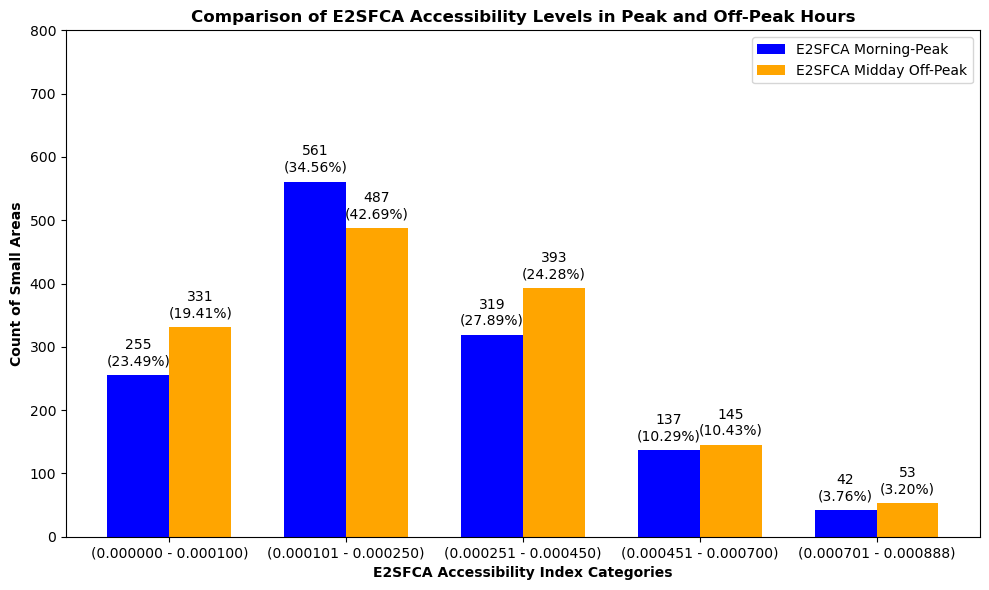

In [303]:
# E2SFCA comparision Bar-chart
categories = ['(0.000000 - 0.000100)','(0.000101 - 0.000250)', '(0.000251 - 0.000450)', '(0.000451 - 0.000700)','(0.000701 - 0.000888)']
count_OP = [331, 487, 393, 145,53]
count_MP = [255, 561, 319, 137,42]

# Calculate total counts for percentage calculation
total_OP = sum(count_OP)
total_MP = sum(count_MP)

# Calculate percentages
percent_OP = [(c / total_OP) * 100 for c in count_OP]
percent_MP = [(c / total_MP) * 100 for c in count_MP]

# Bar chart setup
x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, count_MP, width, label='E2SFCA Morning-Peak', color='blue')
rects2 = ax.bar(x + width/2, count_OP, width, label='E2SFCA Midday Off-Peak', color='orange')

# Labels and title
ax.set_xlabel('E2SFCA Accessibility Index Categories', fontweight='bold')
ax.set_ylabel('Count of Small Areas', fontweight='bold')
ax.set_title('Comparison of E2SFCA Accessibility Levels in Peak and Off-Peak Hours', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Annotate bars with count and percentage
def autolabel(rects, percentages):
    for rect, pct in zip(rects, percentages):
        height = rect.get_height()
        ax.annotate(f'{height:,}\n({pct:.2f}%)',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1, percent_OP)
autolabel(rects2, percent_MP)

# Adjust y-axis to fit labels
ax.set_ylim(0, 800)

fig.tight_layout()
plt.show()
# Save as PNG
fig.savefig(r"D:\GIS-TU Dublin\Year_2\THESIS\REPORT\Maps\new_maps\E2SFCA_comparison.png", dpi=300)

